In [ ]:
# Hour 1 - TP,TN,FN,FP
y_true = [1,0,1,1,0,0,1]
y_pred = [1,0,0,1,0,1,1]

In [2]:
## Hour 3
from sklearn.metrics import confusion_matrix
from sklearn.metrics import confusion_matrix

y_true = [1,0,1,1,0]
y_pred = [1,1,0,1,0]

cm = confusion_matrix(y_true, y_pred)
print(cm)
tn, fp, fn, tp = cm.ravel()

print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

[[1 1]
 [1 2]]
TN: 1
FP: 1
FN: 1
TP: 2


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

X = [[1],[2],[3],[4],[5],[6]]
y = [0,0,0,1,1,1]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1 0]
 [0 1]]
[1, 0]
[1 0]


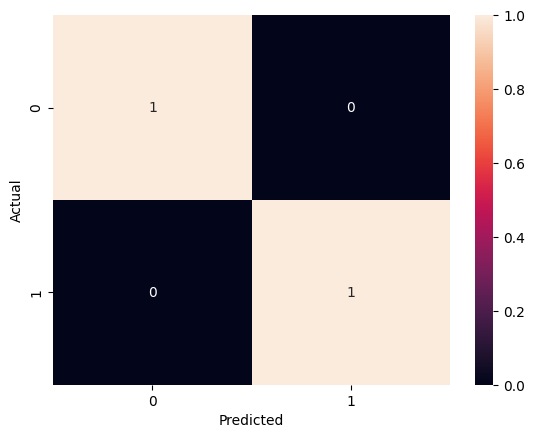

In [4]:
# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
y_true = [1,1,1,1]
y_pred = [1,1,1,1]


y_true = [1,1,1,1]
y_pred = [0,0,0,0]

y_true = [0,1,0,1]
y_pred = [1,0,1,0]

cm = confusion_matrix(y_true, y_pred)
print(cm)

[[0 2]
 [2 0]]


In [14]:
# Hour 7
y_true = [1,0,1,1,0,1,0,0,1,0]
y_prob = [0.9,0.3,0.7,0.4,0.2,0.8,0.6,0.1,0.55,0.45]

thresholds = [0.3, 0.5, 0.7]
# thresholds = 0.3
def predict_with_threshold(y_prob, thresholds):
    return [1 if p >= thresholds else 0 for p in y_prob]

from sklearn.metrics import confusion_matrix

for t in thresholds:
    y_pred = predict_with_threshold(y_prob, t)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    print(f"\nThreshold = {t}")
    print(cm)
    print("TP:", tp, "FP:", fp, "FN:", fn, "TN:", tn)


Threshold = 0.3
[[2 3]
 [0 5]]
TP: 5 FP: 3 FN: 0 TN: 2

Threshold = 0.5
[[4 1]
 [1 4]]
TP: 4 FP: 1 FN: 1 TN: 4

Threshold = 0.7
[[5 0]
 [2 3]]
TP: 3 FP: 0 FN: 2 TN: 5


In [ ]:
# DSA
# Problem 1: Subarray Sum Equals K
nums = [1,2,3]
k = 3

# Find number of subarrays whose sum = k

# 👉 Output: 2
# ([1,2], [3])

def subarray_sum(nums, k):
    prefix_map = {0: 1}
    current_sum = 0
    count = 0
    for num in nums:
        current_sum += num
        if (current_sum - k) in prefix_map:
            count += prefix_map[current_sum - k]
        prefix_map[current_sum] = prefix_map.get(current_sum, 0) + 1
    
    return count

# print(subarray_sum(nums, k))
# nums =[1,1,1]
# k=2  
# nums = [1,-1,0]
# k=0  
nums = [3,4,7,2,-3,1,4,2]
k=7
print(subarray_sum(nums, k))

4


In [ ]:
# Problem 2
# Range Sum Query
nums = [1,2,3,4]
# query: sum from index 1 to 3

class NumArray:
    def __init__(self, nums):
        self.prefix = [0] * len(nums)
        print(self.prefix)
        self.prefix[0] = nums[0]
        
        for i in range(1, len(nums)):
            self.prefix[i] = self.prefix[i-1] + nums[i]
    
    def sumRange(self, left, right):
        if left == 0:
            return self.prefix[right]
        return self.prefix[right] - self.prefix[left-1]
    
d = NumArray(nums)
print(d.sumRange(1,2))

# SIngle Query
nums = [1,2,3,4]
def sum_arr(nums,left,right):
    sm = []
    prefix_sum = 0
    for num in nums:
        prefix_sum+= num
        sm.append(prefix_sum)
    if left == 0:
        return sm[right]
    return sm[right] - sm[left-1]

print(sum_arr(nums,1,2))

# Multiple Query
class NumArray:
    def __init__(self, nums):
        self.prefix = []
        prefix_sum = 0
        
        for num in nums:
            prefix_sum += num
            self.prefix.append(prefix_sum)
    
    def sumRange(self, left, right):
        if left == 0:
            return self.prefix[right]
        return self.prefix[right] - self.prefix[left-1]

[0, 0, 0, 0]
5


In [ ]:
## Longest Subarray with SUm k

nums = [1, -1, 5, -2, 3]
k = 3
def longest_subarray(nums, k):
    prefix_map = {}
    current_sum = 0
    max_len = 0
    
    for i in range(len(nums)):
        current_sum += nums[i]
        
        if current_sum == k:
            max_len = i + 1
        
        if (current_sum - k) in prefix_map:
            max_len = max(max_len, i - prefix_map[current_sum - k])
        
        if current_sum not in prefix_map:
            prefix_map[current_sum] = i
    
    return max_len